In [1]:
!python borough_complaints.py -i data/311_2024.csv -s 2024-01-01 -e 2024-02-29 -o data/janfeb.csv
!python borough_complaints.py -i data/311_2024.csv -s 2024-06-01 -e 2024-07-31 -o data/junjul.csv

In [5]:
import pandas as pd

janfeb = pd.read_csv("data/janfeb.csv")
junjul = pd.read_csv("data/junjul.csv")

totals = janfeb.groupby("complaint type")["count"].sum().sort_values(ascending=False)
top_type = totals.index[0]
print(totals.head(5))
print("Most abundant in Jan–Feb:", top_type)

complaint type
HEAT/HOT WATER          81641
Illegal Parking         79916
Noise - Residential     43602
Blocked Driveway        28608
UNSANITARY CONDITION    19208
Name: count, dtype: int64
Most abundant in Jan–Feb: HEAT/HOT WATER


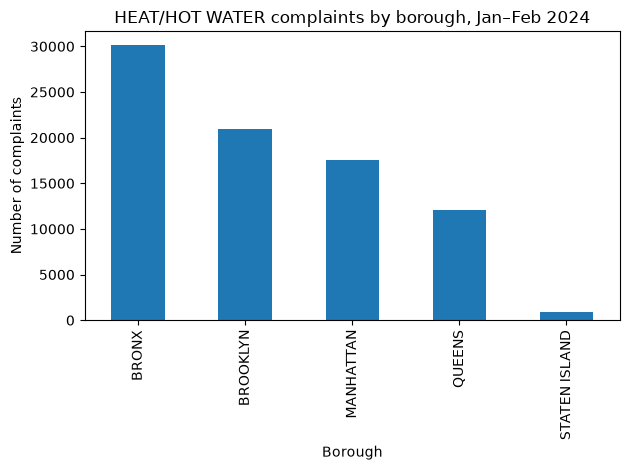

In [3]:
import matplotlib.pyplot as plt

jf = janfeb[janfeb["complaint type"] == top_type].set_index("borough")["count"]

ax = jf.sort_values(ascending=False).plot(kind="bar")
ax.set_title(f"{top_type} complaints by borough, Jan–Feb 2024")
ax.set_xlabel("Borough")
ax.set_ylabel("Number of complaints")
plt.tight_layout()
plt.show()

               Jan–Feb 2024  Jun–Jul 2024
borough                                  
BRONX                 30139          2227
BROOKLYN              20915          1929
MANHATTAN             17604          1778
QUEENS                12117           835
STATEN ISLAND           866           121

Totals:
 Jan–Feb 2024    81641
Jun–Jul 2024     6890
dtype: int64

Top 5 in Jun–Jul:
 complaint type
Illegal Parking            86240
Noise - Residential        58197
Noise - Street/Sidewalk    47320
Blocked Driveway           27193
Water System               21653
Name: count, dtype: int64

Rank of HEAT/HOT WATER in Jun–Jul: 25


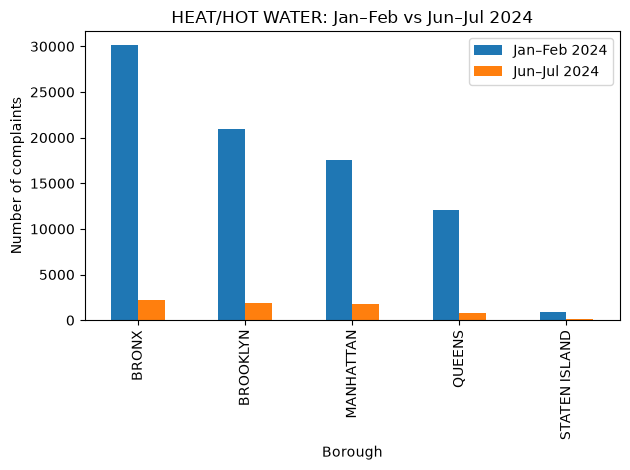

In [4]:
jj = junjul[junjul["complaint type"] == top_type].set_index("borough")["count"]

compare = pd.DataFrame({"Jan–Feb 2024": jf, "Jun–Jul 2024": jj}).fillna(0).astype(int)
print(compare)
print("\nTotals:\n", compare.sum())

jj_totals = junjul.groupby("complaint type")["count"].sum().sort_values(ascending=False)
print("\nTop 5 in Jun–Jul:\n", jj_totals.head(5))
print(f"\nRank of {top_type} in Jun–Jul:", list(jj_totals.index).index(top_type) + 1)

ax = compare.plot(kind="bar")
ax.set_title(f"{top_type}: Jan–Feb vs Jun–Jul 2024")
ax.set_xlabel("Borough")
ax.set_ylabel("Number of complaints")
plt.tight_layout()
plt.show()